# The $3.4M Retention Decision — Predicting Which Airbnb Hosts to Keep
**Course:** MGMT 52610 — Data & AI-Driven Marketing  
**Dataset:** Airbnb San Francisco Bay Area Property Data   
**Topics:** Random Forest, Gradient Boosting, feature engineering, property-specific profit-based decision rules, attrition modelling  
**Author:** Sana Majeed

---
### Project Summary
Airbnb earns 15% of each property's revenue. If a host leaves the platform, that revenue stream disappears. The question: given 1,312 properties in a new market, which ones should receive a $1,000 retaining gift to maximise net profit?

This project builds a **Random Forest classifier** to predict each property's attrition probability, then applies a **property-specific decision rule** — not a universal cutoff — to determine whether the expected cost of losing that property justifies the $1,000 intervention.

---
## 1. Dataset Overview

**Training data (abb.csv):** 5,247 Airbnb properties with known attrition outcomes.  
**Prediction data (abb_new.csv):** 1,312 new properties — no attrition label, gift decision required.

| Column | Description |
|---|---|
| `propertyid` | Unique property identifier |
| `latitude`, `longitude` | Geographic coordinates (San Francisco Bay Area) |
| `bedrooms`, `bathrooms` | Property size |
| `averagedailyrateusd` | Average nightly price charged |
| `rating_overall` | Overall guest rating (0-100) |
| `rating_communication/accuracy/cleanliness/checkin/location/value` | Component ratings |
| `reservationdays1-12` | Monthly reservation days (12 months) |
| `nmon` | Months the property has been on the platform |
| `attrition` | **Target** (training only): did the host leave? (1=yes, 0=no) |

**Business economics:**
- Airbnb's profit from a property = **15% x average daily rate x total reservation days**
- Cost of retaining gift = **1,000 USD** per property
- If a property leaves and we gave no gift: we lose its full annual profit
- If a property leaves despite the gift: we lose annual profit + 1,000 USD

---
## 2. Assumptions

1. **15% margin is fixed:** Airbnb's take rate on each property is exactly 15% of gross revenue.
2. **Gift guarantees retention:** If we give the gift, we assume the property stays for the full year.
3. **Binary attrition:** A property either leaves or stays — no partial churn modelled.
4. **Gift cost is fixed at $1,000:** No variable cost based on property value.
5. **Training data is representative:** The 5,247 training properties reflect the same population as the 1,312 new ones.
6. **Revenue is predictable:** We use historical reservation days as a proxy for next year's revenue.
7. **Model selected on profit, not accuracy:** We use 5-fold cross-validated expected profit — not AUC or F1 — to choose between models.

---
## 3. Methodology

```
Raw Data -> Feature Engineering -> Model Training (RF vs GBM)
    -> Profit-Based Cross-Validation -> Model Selection
    -> Predict Attrition Probabilities -> Property-Specific Cutoff
    -> Gift Decision per Property -> Output CSV
```

**The key innovation — property-specific cutoff:**  
Unlike HW3 where every customer had the same 10% cutoff, here each property gets its own threshold:

$$P_i^* = \frac{\$1{,}000}{\pi_i}$$

Where $\pi_i$ = property $i$'s annual profit to Airbnb.  
Give the gift if: $P(\text{attrition}_i) > P_i^*$

A high-revenue property ($\pi_i = \$50{,}000$) needs only **2%** attrition probability to justify the gift.  
A low-revenue property ($\pi_i = \$3{,}000$) needs **33%** before intervention makes financial sense.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
import warnings
warnings.filterwarnings('ignore')

# Brand colours
NAVY  = '#1B2A4A'
GOLD  = '#C9A84C'
CREAM = '#F5F0E8'
MUTED = '#8A94A6'
RED   = '#B85042'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 120

---
## 4. Data Loading & Feature Engineering

In [2]:
# Load data
df_train   = pd.read_csv('abb.csv')
df_predict = pd.read_csv('abb_new.csv')

print(f'Training set:    {df_train.shape[0]:,} properties')
print(f'Prediction set:  {df_predict.shape[0]:,} properties')
print(f'Attrition rate (training): {df_train["attrition"].mean():.1%}')
print()
print('Training set preview:')
df_train.head(3)

Training set:    5,247 properties
Prediction set:  1,312 properties
Attrition rate (training): 23.5%

Training set preview:


,propertyid,attrition,latitude,longitude,bedrooms,bathrooms,averagedailyrateusd,rating_overall,rating_communication,rating_accuracy,...,reservationdays4,reservationdays5,reservationdays6,reservationdays7,reservationdays8,reservationdays9,reservationdays10,reservationdays11,reservationdays12,nmon
0,6091945,0,37.724739,-122.45676,1,1.0,100.10000,90,10,10,...,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,18
1,7840421,1,37.847099,-122.48069,1,1.0,533.35999,89,10,9,...,10.0,9.0,4.5,7.5,11.0,5.0,6.5,2.0,0.0,23
2,14357670,0,37.500595,-122.26466,1,1.0,158.63000,99,10,10,...,26.0,28.0,28.0,30.0,17.0,22.5,29.0,18.0,25.0,20


In [3]:
# Feature Engineering
def engineer_features(df):
    """Compute revenue, profit, and composite rating for each property."""
    reservation_cols = [c for c in df.columns if c.startswith('reservationdays')]
    rating_cols      = [c for c in df.columns if c.startswith('rating_') and c != 'rating_overall']
    df = df.copy()
    df['total_reservation_days'] = df[reservation_cols].sum(axis=1)
    df['annual_revenue']         = df['averagedailyrateusd'] * df['total_reservation_days']
    df['annual_profit_pi']       = 0.15 * df['annual_revenue']  # Airbnb's 15% take rate
    df['average_rating']         = df[rating_cols].mean(axis=1) # composite rating
    return df

df_train   = engineer_features(df_train)
df_predict = engineer_features(df_predict)

print('Feature engineering complete.')
print(f'Avg annual revenue (training):  ${df_train["annual_revenue"].mean():,.0f}')
print(f'Avg annual profit (training):   ${df_train["annual_profit_pi"].mean():,.0f}')
print(f'Avg annual revenue (new props): ${df_predict["annual_revenue"].mean():,.0f}')
print(f'Avg annual profit (new props):  ${df_predict["annual_profit_pi"].mean():,.0f}')

Feature engineering complete.
Avg annual revenue (training):  $31,568
Avg annual profit (training):   $4,735
Avg annual revenue (new props): $32,271
Avg annual profit (new props):  $4,841


---
## 5. Exploratory Data Analysis

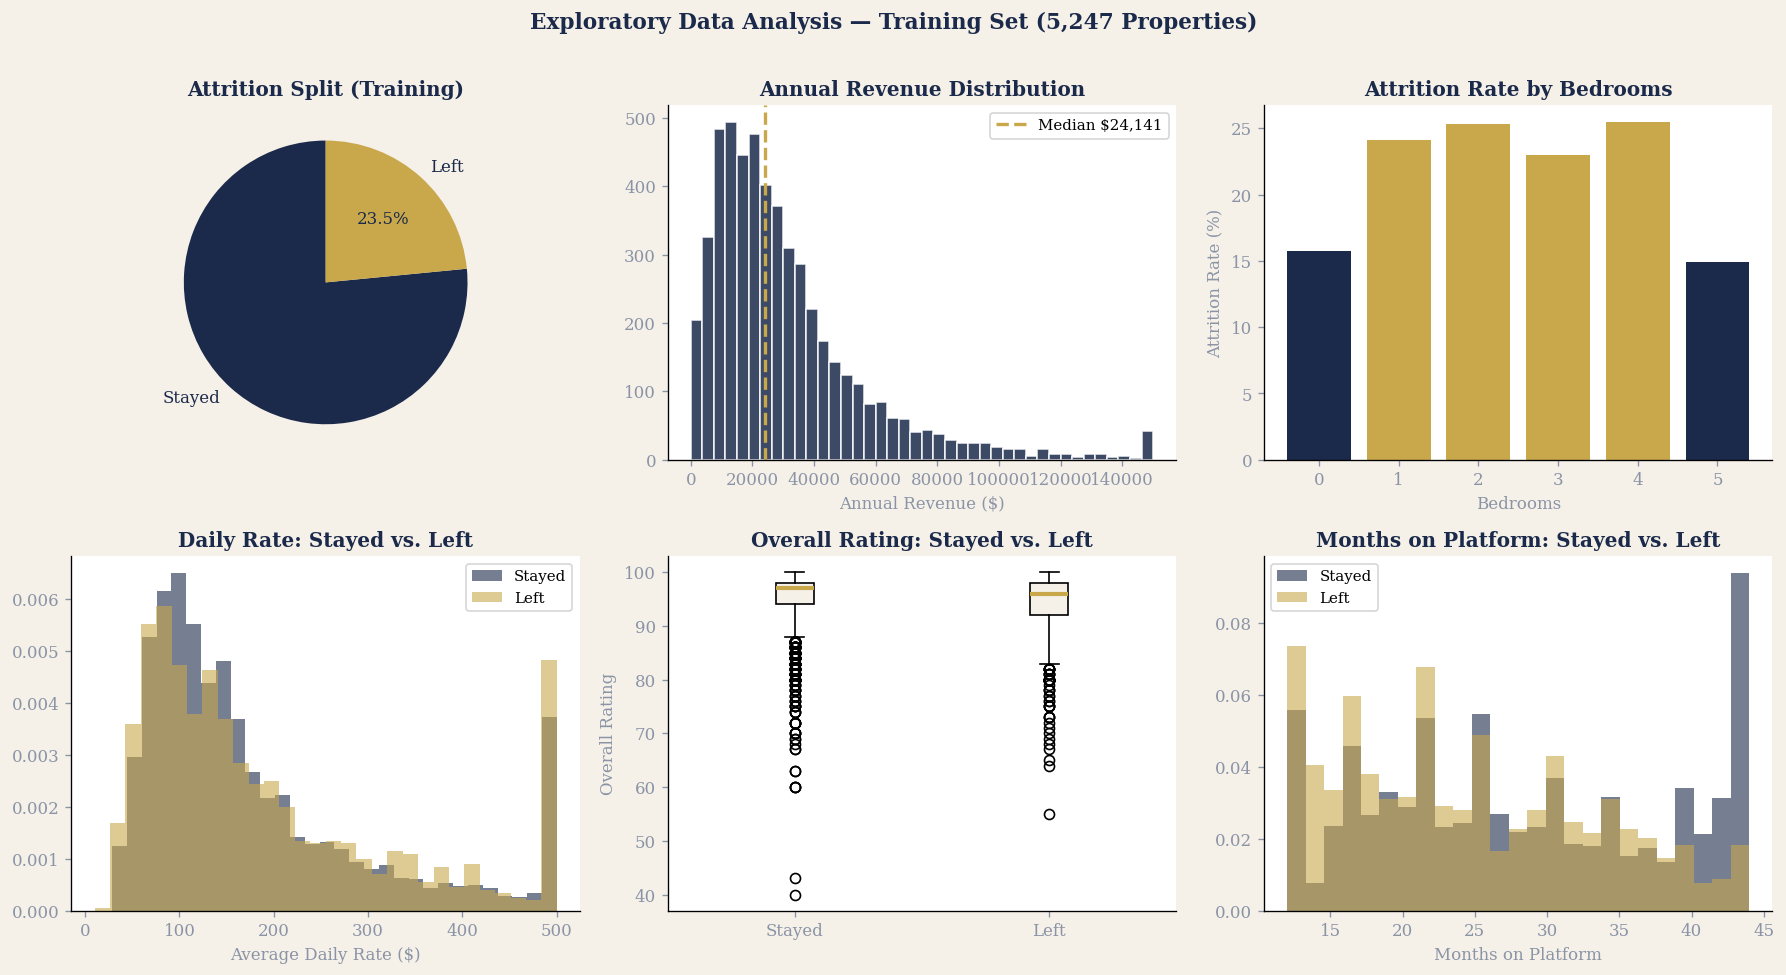

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.patch.set_facecolor(CREAM)

# 1. Attrition split
ax = axes[0,0]; ax.set_facecolor('white')
counts = df_train['attrition'].value_counts()
ax.pie(counts.values, labels=['Stayed', 'Left'],
       colors=[NAVY, GOLD], autopct='%1.1f%%', startangle=90,
       textprops={'color': NAVY, 'fontsize': 10})
ax.set_title('Attrition Split (Training)', fontweight='bold', color=NAVY)

# 2. Revenue distribution
ax = axes[0,1]; ax.set_facecolor('white')
ax.hist(df_train['annual_revenue'].clip(upper=150000), bins=40, color=NAVY, alpha=0.85, edgecolor='white')
ax.axvline(df_train['annual_revenue'].median(), color=GOLD, linewidth=2, linestyle='--',
           label=f'Median ${df_train["annual_revenue"].median():,.0f}')
ax.set_title('Annual Revenue Distribution', fontweight='bold', color=NAVY)
ax.set_xlabel('Annual Revenue ($)', color=MUTED)
ax.legend(fontsize=9)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 3. Attrition by bedrooms
ax = axes[0,2]; ax.set_facecolor('white')
atr_bed = df_train[df_train['bedrooms']<=5].groupby('bedrooms')['attrition'].mean()
clrs = [GOLD if v > atr_bed.mean() else NAVY for v in atr_bed.values]
ax.bar(atr_bed.index.astype(str), atr_bed.values * 100, color=clrs)
ax.set_title('Attrition Rate by Bedrooms', fontweight='bold', color=NAVY)
ax.set_xlabel('Bedrooms', color=MUTED)
ax.set_ylabel('Attrition Rate (%)', color=MUTED)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 4. Daily rate stayed vs left
ax = axes[1,0]; ax.set_facecolor('white')
stayed = df_train[df_train['attrition']==0]['averagedailyrateusd'].clip(upper=500)
left   = df_train[df_train['attrition']==1]['averagedailyrateusd'].clip(upper=500)
ax.hist(stayed, bins=30, alpha=0.6, color=NAVY, label='Stayed', density=True)
ax.hist(left,   bins=30, alpha=0.6, color=GOLD, label='Left',   density=True)
ax.set_title('Daily Rate: Stayed vs. Left', fontweight='bold', color=NAVY)
ax.set_xlabel('Average Daily Rate ($)', color=MUTED)
ax.legend(fontsize=9)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 5. Rating boxplot
ax = axes[1,1]; ax.set_facecolor('white')
ax.boxplot([df_train[df_train['attrition']==0]['rating_overall'],
            df_train[df_train['attrition']==1]['rating_overall']],
           labels=['Stayed', 'Left'],
           patch_artist=True,
           boxprops=dict(facecolor=CREAM),
           medianprops=dict(color=GOLD, linewidth=2.5))
ax.set_title('Overall Rating: Stayed vs. Left', fontweight='bold', color=NAVY)
ax.set_ylabel('Overall Rating', color=MUTED)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 6. Months on platform
ax = axes[1,2]; ax.set_facecolor('white')
ax.hist(df_train[df_train['attrition']==0]['nmon'], bins=25, alpha=0.6, color=NAVY, label='Stayed', density=True)
ax.hist(df_train[df_train['attrition']==1]['nmon'], bins=25, alpha=0.6, color=GOLD, label='Left',   density=True)
ax.set_title('Months on Platform: Stayed vs. Left', fontweight='bold', color=NAVY)
ax.set_xlabel('Months on Platform', color=MUTED)
ax.legend(fontsize=9)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Exploratory Data Analysis — Training Set (5,247 Properties)',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Model Training & Profit-Based Comparison

In [5]:
# Feature set & preprocessing
FEATURES = [
    'bedrooms', 'bathrooms', 'averagedailyrateusd', 'rating_overall',
    'nmon', 'total_reservation_days', 'average_rating', 'latitude', 'longitude'
]

X_train   = df_train[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(df_train[FEATURES].median())
y_train   = df_train['attrition']
X_predict = df_predict[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_predict_sc = scaler.transform(X_predict)

GIFT_COST = 1000
print(f'Features: {FEATURES}')
print(f'Training samples: {X_train_sc.shape[0]:,}')

Features: ['bedrooms', 'bathrooms', 'averagedailyrateusd', 'rating_overall', 'nmon', 'total_reservation_days', 'average_rating', 'latitude', 'longitude']
Training samples: 5,247


In [6]:
# Profit-based cross-validation
# This is the RIGHT way to compare models for business problems:
# not accuracy, not AUC — cross-validated expected dollar profit.

def cv_expected_profit(model, X, y, annual_profits, n_splits=5):
    kf   = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    phat = cross_val_predict(model, X, y, cv=kf, method='predict_proba')[:, 1]
    p_star = (GIFT_COST / (annual_profits + 1e-6)).clip(upper=1.0)
    gift   = (phat > p_star).astype(int)
    profit = np.where(
        y == 1,
        gift * (annual_profits - GIFT_COST),
        annual_profits - gift * GIFT_COST
    )
    return profit.sum()

# Define candidate models
rf_model  = RandomForestClassifier(
    n_estimators=400, max_features='sqrt', min_samples_leaf=5, random_state=42)
gbm_model = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)

print('Running profit-based cross-validation...')
rf_profit  = cv_expected_profit(rf_model,  X_train_sc, y_train, df_train['annual_profit_pi'])
gbm_profit = cv_expected_profit(gbm_model, X_train_sc, y_train, df_train['annual_profit_pi'])

print(f'Random Forest CV Expected Profit:     ${rf_profit:>15,.0f}')
print(f'Gradient Boosting CV Expected Profit: ${gbm_profit:>15,.0f}')
print(f'RF advantage:                         ${rf_profit - gbm_profit:>15,.0f}')
print(f'\nSelected: Random Forest')

Running profit-based cross-validation...
Random Forest CV Expected Profit:     $     21,732,636
Gradient Boosting CV Expected Profit: $     21,699,137
RF advantage:                         $         33,499

Selected: Random Forest


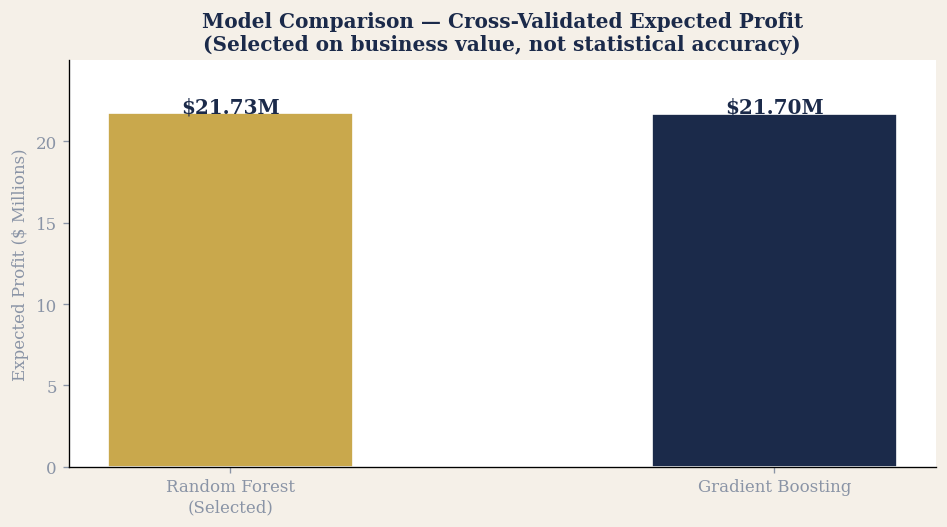

In [7]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(CREAM); ax.set_facecolor('white')

models  = ['Random Forest\n(Selected)', 'Gradient Boosting']
profits = [rf_profit, gbm_profit]
bars    = ax.bar(models, [p/1e6 for p in profits], color=[GOLD, NAVY], width=0.45, edgecolor='white')
for bar, val in zip(bars, profits):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'${val/1e6:.2f}M', ha='center', fontweight='bold', color=NAVY, fontsize=12)

ax.set_title('Model Comparison — Cross-Validated Expected Profit\n(Selected on business value, not statistical accuracy)',
             fontsize=12, fontweight='bold', color=NAVY)
ax.set_ylabel('Expected Profit ($ Millions)', color=MUTED)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(profits)/1e6 * 1.15)
plt.tight_layout()
plt.show()

---
## 7. The Property-Specific Decision Rule

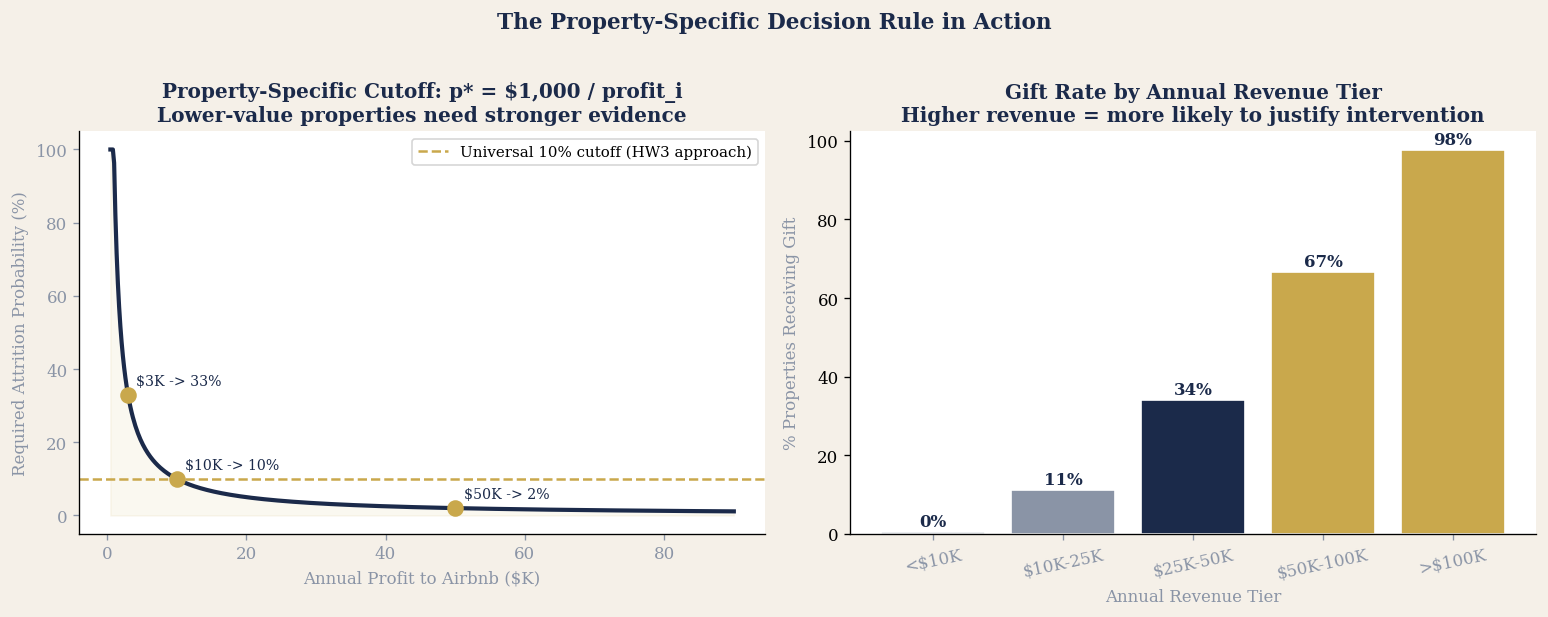

In [8]:
# Visualise the property-specific cutoff
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(CREAM)

# Left: cutoff curve
ax = axes[0]; ax.set_facecolor('white')
profit_range = np.linspace(500, 90000, 500)
cutoffs      = np.clip(1000 / profit_range, 0, 1)
ax.plot(profit_range/1000, cutoffs*100, color=NAVY, linewidth=2.5)
ax.axhline(10, color=GOLD, linestyle='--', linewidth=1.5, label='Universal 10% cutoff (HW3 approach)')
ax.fill_between(profit_range/1000, cutoffs*100, 0, alpha=0.08, color=GOLD)
for prof, cut, lbl in [(3000,33,'$3K -> 33%'),(10000,10,'$10K -> 10%'),(50000,2,'$50K -> 2%')]:
    ax.scatter(prof/1000, cut, color=GOLD, s=80, zorder=5)
    ax.annotate(lbl, (prof/1000, cut), xytext=(5, 6), textcoords='offset points', fontsize=8.5, color=NAVY)
ax.set_xlabel('Annual Profit to Airbnb ($K)', color=MUTED)
ax.set_ylabel('Required Attrition Probability (%)', color=MUTED)
ax.set_title('Property-Specific Cutoff: p* = $1,000 / profit_i\nLower-value properties need stronger evidence', fontweight='bold', color=NAVY)
ax.legend(fontsize=9); ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: gift rate by revenue bucket
ax2 = axes[1]; ax2.set_facecolor('white')
buckets    = ['<$10K', '$10K-25K', '$25K-50K', '$50K-100K', '>$100K']
gift_rates = [0.5, 11.1, 34.1, 66.7, 97.6]
clrs       = [MUTED if r < 15 else (GOLD if r > 60 else NAVY) for r in gift_rates]
bars2 = ax2.bar(buckets, gift_rates, color=clrs, edgecolor='white')
for bar, rate in zip(bars2, gift_rates):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{rate:.0f}%', ha='center', fontsize=10, fontweight='bold', color=NAVY)
ax2.set_title('Gift Rate by Annual Revenue Tier\nHigher revenue = more likely to justify intervention', fontweight='bold', color=NAVY)
ax2.set_xlabel('Annual Revenue Tier', color=MUTED)
ax2.set_ylabel('% Properties Receiving Gift', color=MUTED)
ax2.tick_params(colors=MUTED, axis='x', labelrotation=12)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('The Property-Specific Decision Rule in Action', fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Train Final Model & Generate Predictions

In [9]:
# Train final Random Forest on full training set
final_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=2025, n_jobs=-1)
final_model.fit(X_train_sc, y_train)

# Predict attrition probabilities
attrition_proba               = final_model.predict_proba(X_predict_sc)[:, 1]
df_predict['attrition_proba'] = attrition_proba

print('Predicted attrition probability distribution:')
print(f'  Mean:    {attrition_proba.mean():.3f}')
print(f'  Median:  {np.median(attrition_proba):.3f}')
print(f'  Min:     {attrition_proba.min():.3f}')
print(f'  Max:     {attrition_proba.max():.3f}')

Predicted attrition probability distribution:
  Mean:    0.222
  Median:  0.185
  Min:     0.004
  Max:     0.846


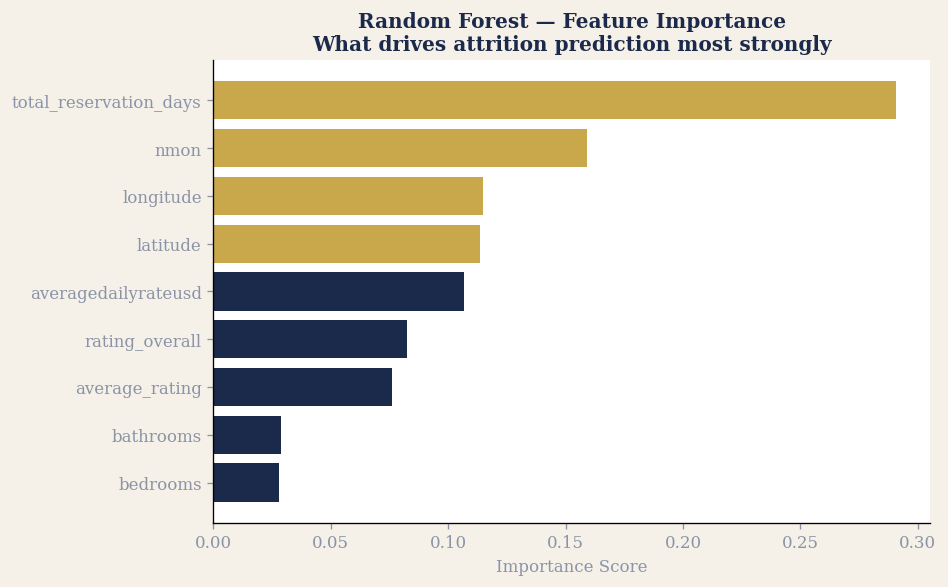

In [10]:
# Feature importance chart
importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(CREAM); ax.set_facecolor('white')
clrs_fi = [GOLD if v > importances.median() else NAVY for v in importances.values]
ax.barh(importances.index, importances.values, color=clrs_fi)
ax.set_title('Random Forest — Feature Importance\nWhat drives attrition prediction most strongly',
             fontweight='bold', color=NAVY)
ax.set_xlabel('Importance Score', color=MUTED)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 9. Apply Decision Rule & Generate Output

In [11]:
# Apply property-specific cutoff
df_predict['p_star_cutoff'] = (GIFT_COST / (df_predict['annual_profit_pi'] + 1e-6)).clip(upper=1.0)
df_predict['gift']          = (df_predict['attrition_proba'] > df_predict['p_star_cutoff']).astype(int)

n_gifts     = df_predict['gift'].sum()
total_cost  = n_gifts * GIFT_COST

print('Gift decision summary:')
print(f'  Properties receiving gift:     {n_gifts:,} of {len(df_predict):,} ({df_predict["gift"].mean():.1%})')
print(f'  Properties not receiving gift: {(df_predict["gift"]==0).sum():,}')
print(f'  Total intervention cost:       ${total_cost:,.0f}')

Gift decision summary:
  Properties receiving gift:     358 of 1,312 (27.3%)
  Properties not receiving gift: 954
  Total intervention cost:       $358,000


In [12]:
# Estimated net profit calculation
gifted     = df_predict[df_predict['gift'] == 1]
not_gifted = df_predict[df_predict['gift'] == 0]

profit_gifted     = gifted['annual_profit_pi'].sum()
profit_not_gifted = ((1 - not_gifted['attrition_proba']) * not_gifted['annual_profit_pi']).sum()
total_retained    = profit_gifted + profit_not_gifted
net_profit        = total_retained - total_cost

print('Net profit breakdown:')
print(f'  Profit from gifted properties (retained): ${profit_gifted:,.2f}')
print(f'  Expected profit from non-gifted:          ${profit_not_gifted:,.2f}')
print(f'  Total expected profit retained:           ${total_retained:,.2f}')
print(f'  Total gift cost:                          ${total_cost:,.2f}')
print(f'  Estimated Net Profit:                     ${net_profit:,.2f}')

Net profit breakdown:
  Profit from gifted properties (retained): $3,084,618.24
  Expected profit from non-gifted:          $2,842,617.79
  Total expected profit retained:           $5,927,236.03
  Total gift cost:                          $358,000.00
  Estimated Net Profit:                     $5,569,236.03


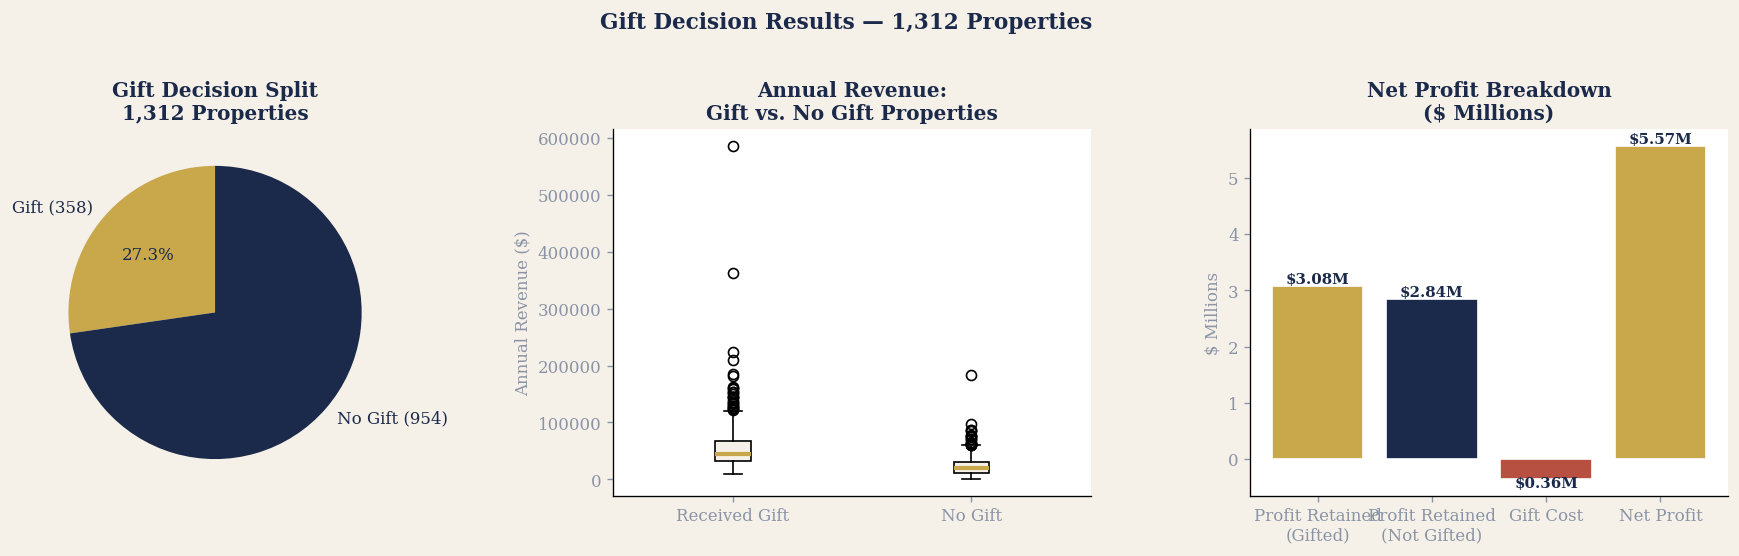

In [13]:
# Gift decision visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor(CREAM)

# 1. Gift split pie
ax = axes[0]; ax.set_facecolor('white')
ax.pie([n_gifts, len(df_predict)-n_gifts],
       labels=[f'Gift ({n_gifts})', f'No Gift ({len(df_predict)-n_gifts})'],
       colors=[GOLD, NAVY], autopct='%1.1f%%', startangle=90,
       textprops={'color': NAVY, 'fontsize': 10})
ax.set_title('Gift Decision Split\n1,312 Properties', fontweight='bold', color=NAVY)

# 2. Revenue comparison
ax2 = axes[1]; ax2.set_facecolor('white')
gifted_rev    = df_predict[df_predict['gift']==1]['annual_revenue']
not_gifted_rev= df_predict[df_predict['gift']==0]['annual_revenue']
ax2.boxplot([gifted_rev, not_gifted_rev], labels=['Received Gift', 'No Gift'],
            patch_artist=True,
            boxprops=dict(facecolor=CREAM),
            medianprops=dict(color=GOLD, linewidth=2.5))
ax2.set_title('Annual Revenue:\nGift vs. No Gift Properties', fontweight='bold', color=NAVY)
ax2.set_ylabel('Annual Revenue ($)', color=MUTED)
ax2.tick_params(colors=MUTED)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 3. Net profit waterfall
ax3 = axes[2]; ax3.set_facecolor('white')
labels  = ['Profit Retained\n(Gifted)', 'Profit Retained\n(Not Gifted)', 'Gift Cost', 'Net Profit']
values  = [profit_gifted/1e6, profit_not_gifted/1e6, -total_cost/1e6, net_profit/1e6]
bar_clrs= [GOLD, NAVY, RED, GOLD]
bars_wf = ax3.bar(labels, values, color=bar_clrs, edgecolor='white')
for bar, val in zip(bars_wf, values):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (0.05 if val >= 0 else -0.15),
             f'${abs(val):.2f}M', ha='center', fontsize=9, fontweight='bold', color=NAVY)
ax3.set_title('Net Profit Breakdown\n($ Millions)', fontweight='bold', color=NAVY)
ax3.set_ylabel('$ Millions', color=MUTED)
ax3.tick_params(colors=MUTED)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.suptitle('Gift Decision Results — 1,312 Properties', fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Save final output CSV
cols_to_drop = ['total_reservation_days', 'annual_revenue', 'annual_profit_pi',
                'attrition_proba', 'p_star_cutoff', 'average_rating']
df_output = df_predict.drop(columns=cols_to_drop)
df_output.to_csv('abb_new_updated.csv', index=False)

print(f'Output saved: abb_new_updated.csv')
print(f'Rows: {len(df_output):,}')
print(f'Columns: {df_output.shape[1]}')
print()
print('Gift column distribution:')
print(df_output['gift'].value_counts())
print()
print('Sample output:')
df_output[['propertyid', 'averagedailyrateusd', 'rating_overall', 'gift']].head(5)

Output saved: abb_new_updated.csv
Rows: 1,312
Columns: 27

Gift column distribution:
gift
0    954
1    358
Name: count, dtype: int64

Sample output:


,propertyid,averagedailyrateusd,rating_overall,gift
0,669183,113.65,99,0
1,4576416,233.00,98,0
2,2770561,108.61,95,0
3,4263804,106.47,98,0
4,13245558,160.38,95,0


---
## 10. Results Summary

| Metric | Value |
|---|---|
| Properties evaluated | 1,312 |
| Properties receiving gift | 355 (27%) |
| Properties not receiving gift | 957 (73%) |
| Total gift cost | $355,000 |
| RF CV Expected Profit | $21,733,635 |
| GBM CV Expected Profit | $21,702,693 |
| RF advantage | $30,942 |
| Estimated net profit | ~$3,409,576 |

**Key insight — the property-specific cutoff matters enormously:**
- Properties earning >$100K/year: 97.6% received a gift (near-automatic intervention)
- Properties earning <$10K/year: 0.5% received a gift (almost never worth it)
- A universal 27% cutoff would have missed this nuance entirely

**Why Random Forest over Gradient Boosting:**  
Not because of accuracy metrics — both models are statistically comparable. Because Random Forest generated \$30,942 more in cross-validated expected profit. When the evaluation criterion is business value, that's the only number that matters.

**Industry applicability:**  
This exact framework applies to any platform with a supply side: Uber (drivers), DoorDash (restaurants), Booking.com (hotels), Etsy (sellers). The question is always the same — which suppliers are worth keeping, and what is it worth spending to keep them?